# Import CSV file To colabNotbook

In [1]:
from google.colab import files

uploaded = files.upload()

Saving netflix_churn_dataset.csv to netflix_churn_dataset.csv


# Importing needed librarys

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To read csv file in pandas

In [3]:
df = pd.read_csv("netflix_churn_dataset.csv")

df.head()

,customer_id,age,gender,country,subscription_type,monthly_charges,tenure_months,num_profiles,device,payment_method,autopay_enabled,watch_hours_per_week,favorite_genre,avg_rating_given,support_tickets_raised,last_login_days_ago,promo_used,churn
0,CUST100000,51,Female,USA,Basic,206,45,2,Smart TV,Debit Card,Yes,2.7,Horror,3.9,0,45,No,No
1,CUST100001,64,Female,UK,Standard,507,28,5,Mobile,PayPal,Yes,1.9,Documentary,3.0,2,26,No,Yes
2,CUST100002,41,Male,Canada,Basic,208,12,1,Mobile,Debit Card,Yes,7.0,Anime,1.7,1,69,No,No
3,CUST100003,27,Male,USA,Basic,195,35,5,Smart TV,PayPal,Yes,9.0,Thriller,3.7,0,30,Yes,No
4,CUST100004,55,Female,Australia,Standard,496,22,5,Laptop,Debit Card,Yes,8.0,Thriller,3.8,1,40,No,No


# check the total number of rows, columns, and missing values in the dataset using .info() and .isnull().sum()?

In [4]:
# using .info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             4000 non-null   object 
 1   age                     4000 non-null   int64  
 2   gender                  4000 non-null   object 
 3   country                 4000 non-null   object 
 4   subscription_type       4000 non-null   object 
 5   monthly_charges         4000 non-null   int64  
 6   tenure_months           4000 non-null   int64  
 7   num_profiles            4000 non-null   int64  
 8   device                  4000 non-null   object 
 9   payment_method          4000 non-null   object 
 10  autopay_enabled         4000 non-null   object 
 11  watch_hours_per_week    4000 non-null   float64
 12  favorite_genre          4000 non-null   object 
 13  avg_rating_given        4000 non-null   float64
 14  support_tickets_raised  4000 non-null   

# data looks neet and clean

# let's find null values usnig .isnull().sum()

In [5]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
country,0
subscription_type,0
monthly_charges,0
tenure_months,0
num_profiles,0
device,0
payment_method,0


# There are zero null values in df

# Now Find How many customers churned versus stayed

In [6]:
df.head(2)

,customer_id,age,gender,country,subscription_type,monthly_charges,tenure_months,num_profiles,device,payment_method,autopay_enabled,watch_hours_per_week,favorite_genre,avg_rating_given,support_tickets_raised,last_login_days_ago,promo_used,churn
0,CUST100000,51,Female,USA,Basic,206,45,2,Smart TV,Debit Card,Yes,2.7,Horror,3.9,0,45,No,No
1,CUST100001,64,Female,UK,Standard,507,28,5,Mobile,PayPal,Yes,1.9,Documentary,3.0,2,26,No,Yes


In [7]:
churned = df['churn'].value_counts()['Yes']

stayed = df['churn'].value_counts()['No']

print(f'Number of customers who churned: {churned}')
print(f'Number of customers who stayed: {stayed}')


Number of customers who churned: 801
Number of customers who stayed: 3199


# Now Find Which subscription tier (subscription_type) has the highest number of churned users?

In [8]:
churn_counts_by_type = df.groupby('subscription_type')['churn'].value_counts()
churned_users_by_type = churn_counts_by_type.xs('Yes', level='churn')
highest_churn_subscription = churned_users_by_type.idxmax()

print("Number of churned users by subscription type:")
print(churned_users_by_type)
print(f"\nThe subscription tier with the highest number of churned users is: {highest_churn_subscription}")

Number of churned users by subscription type:
subscription_type
Basic       319
Premium     194
Standard    288
Name: count, dtype: int64

The subscription tier with the highest number of churned users is: Basic


# Now find What is the average monthly_charges and average watch_hours_per_week for churned users compared to active users using .groupby()

In [9]:
print(df['churn'].unique())

['No' 'Yes']


# mapping 1,0 in the place of Yes,No

In [10]:
df['churn']=df['churn'].map({'Yes': 1, 'No': 0})



# count values

In [11]:
print(df['churn'].value_counts(dropna=False))

churn
0    3199
1     801
Name: count, dtype: int64


# Average monthly charges vs Average watch hours per week

In [12]:
average_monthly_charges = df.groupby('churn')['monthly_charges'].mean()

average_watch_hours_per_week = df.groupby('churn')['watch_hours_per_week'].mean()

print("Average monthly charges:")
print("Active users:", round(average_monthly_charges[0],2))
print("Churned users:", round(average_monthly_charges[1],2))

print("\nAverage watch hours per week:")
print("Active users:",round(average_watch_hours_per_week[0],2))
print("Churned users:", round(average_watch_hours_per_week[1],2))

Average monthly charges:
Active users: 434.47
Churned users: 415.27

Average watch hours per week:
Active users: 8.17
Churned users: 6.64


# How can you filter the dataset to find only users who have logged in more than 30 days ago (last_login_days_ago > 30)

In [13]:
df_last_login_days = df[df['last_login_days_ago'] > 30]
df_last_login_days

,customer_id,age,gender,country,subscription_type,monthly_charges,tenure_months,num_profiles,device,payment_method,autopay_enabled,watch_hours_per_week,favorite_genre,avg_rating_given,support_tickets_raised,last_login_days_ago,promo_used,churn
0,CUST100000,51,Female,USA,Basic,206,45,2,Smart TV,Debit Card,Yes,2.7,Horror,3.9,0,45,No,0
2,CUST100002,41,Male,Canada,Basic,208,12,1,Mobile,Debit Card,Yes,7.0,Anime,1.7,1,69,No,0
4,CUST100004,55,Female,Australia,Standard,496,22,5,Laptop,Debit Card,Yes,8.0,Thriller,3.8,1,40,No,0
5,CUST100005,20,Male,UK,Standard,501,39,1,Smart TV,Credit Card,Yes,3.5,Horror,1.9,3,44,No,0
6,CUST100006,73,Male,USA,Premium,656,1,1,Mobile,Credit Card,Yes,5.5,Anime,4.2,0,35,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3988,CUST103988,14,Female,Japan,Basic,195,24,1,Laptop,PayPal,Yes,3.2,Action,3.5,0,67,Yes,1
3992,CUST103992,60,Male,USA,Standard,502,52,4,Smart TV,Debit Card,Yes,8.6,Romance,4.8,1,78,Yes,0
3993,CUST103993,63,Female,Canada,Basic,208,3,2,Laptop,Credit Card,Yes,0.8,Comedy,3.4,0,44,No,1
3997,CUST103997,24,Female,Canada,Standard,501,7,2,Laptop,PayPal,Yes,6.4,Documentary,5.0,0,79,Yes,0


# average 'monthly_charges', 'watch_hours_per_week'

In [14]:
avg_values = df.groupby('churn')[['monthly_charges', 'watch_hours_per_week']].mean()

print(round(avg_values),1)

       monthly_charges  watch_hours_per_week
churn                                       
0                434.0                   8.0
1                415.0                   7.0 1


# filter for "high-risk" active users—those with last_login_days_ago > 30, watch_hours_per_week < 5, and support_tickets_raised >= 2

In [25]:
high_risk_active_users = df[
    (df['last_login_days_ago'] > 30) &
    (df['watch_hours_per_week'] < 5) &
    (df['churn'] == 0)&
    (df['support_tickets_raised'] >= 2)]


high_risk_active_users

,customer_id,age,gender,country,subscription_type,monthly_charges,tenure_months,num_profiles,device,payment_method,autopay_enabled,watch_hours_per_week,favorite_genre,avg_rating_given,support_tickets_raised,last_login_days_ago,promo_used,churn,total_lifetime_spend
5,CUST100005,20,Male,UK,Standard,501,39,1,Smart TV,Credit Card,Yes,3.5,Horror,1.9,3,44,No,0,19539
129,CUST100129,27,Male,Brazil,Standard,507,47,1,Smart TV,UPI,Yes,2.3,Comedy,4.4,2,44,No,0,23829
154,CUST100154,19,Male,Australia,Premium,647,46,3,Smart TV,Credit Card,No,1.4,Horror,4.6,3,57,Yes,0,29762
305,CUST100305,23,Male,USA,Premium,653,49,2,Smart TV,Credit Card,No,3.3,Documentary,3.1,2,78,No,0,31997
343,CUST100343,30,Female,India,Premium,651,44,5,Smart TV,UPI,No,4.9,Thriller,4.0,2,46,No,0,28644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,CUST103595,42,Female,France,Standard,500,27,4,Laptop,Debit Card,Yes,3.7,Comedy,3.4,2,71,No,0,13500
3780,CUST103780,42,Male,Japan,Standard,496,29,2,Smart TV,Credit Card,Yes,3.6,Action,2.9,2,35,Yes,0,14384
3860,CUST103860,69,Other,Mexico,Basic,207,38,3,Laptop,Debit Card,Yes,2.1,Anime,1.7,2,79,Yes,0,7866
3921,CUST103921,32,Other,USA,Basic,194,47,4,Tablet,PayPal,Yes,1.6,Anime,4.3,2,48,No,0,9118


# calculate the total lost revenue by summing monthly_charges * tenure_months exclusively for churned customers

In [26]:
total_lost_revenue = df[df['churn'] == 1]['monthly_charges'] * df[df['churn'] == 1]['tenure_months']
total_lost_revenue = total_lost_revenue.sum()

print(f"Total lost revenue by churned customers: ${total_lost_revenue:.2f}")

Total lost revenue by churned customers: $10009304.00


# NumPy

# the minimum, maximum, and median watch hours per week

In [15]:
minimum_value = np.min(df['watch_hours_per_week'])
maximum_value = np.max(df['watch_hours_per_week'])
median_value = np.median(df['watch_hours_per_week'])

print(f"Minimum value: {minimum_value}")
print(f"Maximum value: {maximum_value}")
print(f"Median value: {median_value}")

Minimum value: 0.0
Maximum value: 60.0
Median value: 5.5


# np.select() with multiple conditions to assign risk tiers (Low, Medium, High) based on last_login_days_ago and watch_hours_per_week

In [27]:
df[['last_login_days_ago','watch_hours_per_week']]

,last_login_days_ago,watch_hours_per_week
0,45,2.7
1,26,1.9
2,69,7.0
3,30,9.0
4,40,8.0
...,...,...
3995,25,8.3
3996,7,5.4
3997,79,6.4
3998,31,5.6


In [28]:
risk_tiers = [
    (df['last_login_days_ago'] > 30) & (df['watch_hours_per_week'] < 5),
    (df['last_login_days_ago'] <= 30) & (df['watch_hours_per_week'] >= 10),
    (df['last_login_days_ago'] <= 30) & (df['watch_hours_per_week'] < 10)
]

risk_tier_labels = ['Low', 'Medium', 'High']

df['risk_tier'] = np.select(risk_tiers, risk_tier_labels, default='Unknown')

df

,customer_id,age,gender,country,subscription_type,monthly_charges,tenure_months,num_profiles,device,payment_method,autopay_enabled,watch_hours_per_week,favorite_genre,avg_rating_given,support_tickets_raised,last_login_days_ago,promo_used,churn,total_lifetime_spend,risk_tier
0,CUST100000,51,Female,USA,Basic,206,45,2,Smart TV,Debit Card,Yes,2.7,Horror,3.9,0,45,No,0,9270,Low
1,CUST100001,64,Female,UK,Standard,507,28,5,Mobile,PayPal,Yes,1.9,Documentary,3.0,2,26,No,1,14196,High
2,CUST100002,41,Male,Canada,Basic,208,12,1,Mobile,Debit Card,Yes,7.0,Anime,1.7,1,69,No,0,2496,Unknown
3,CUST100003,27,Male,USA,Basic,195,35,5,Smart TV,PayPal,Yes,9.0,Thriller,3.7,0,30,Yes,0,6825,High
4,CUST100004,55,Female,Australia,Standard,496,22,5,Laptop,Debit Card,Yes,8.0,Thriller,3.8,1,40,No,0,10912,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,CUST103995,51,Male,UK,Standard,506,29,2,Mobile,Credit Card,Yes,8.3,Romance,4.0,0,25,No,0,14674,High
3996,CUST103996,34,Female,Australia,Premium,656,34,2,Gaming Console,PayPal,Yes,5.4,Comedy,3.1,0,7,No,0,22304,High
3997,CUST103997,24,Female,Canada,Standard,501,7,2,Laptop,PayPal,Yes,6.4,Documentary,5.0,0,79,Yes,0,3507,Unknown
3998,CUST103998,36,Female,USA,Premium,656,17,2,Mobile,Credit Card,No,5.6,Romance,3.7,0,31,No,0,11152,Unknown


# the total lifetime spend for each user by multiplying monthly_charges and tenure_months

In [29]:
total_lifetime_spend = df['monthly_charges'] * df['tenure_months']

df['total_lifetime_spend'] = total_lifetime_spend
df

,customer_id,age,gender,country,subscription_type,monthly_charges,tenure_months,num_profiles,device,payment_method,autopay_enabled,watch_hours_per_week,favorite_genre,avg_rating_given,support_tickets_raised,last_login_days_ago,promo_used,churn,total_lifetime_spend,risk_tier
0,CUST100000,51,Female,USA,Basic,206,45,2,Smart TV,Debit Card,Yes,2.7,Horror,3.9,0,45,No,0,9270,Low
1,CUST100001,64,Female,UK,Standard,507,28,5,Mobile,PayPal,Yes,1.9,Documentary,3.0,2,26,No,1,14196,High
2,CUST100002,41,Male,Canada,Basic,208,12,1,Mobile,Debit Card,Yes,7.0,Anime,1.7,1,69,No,0,2496,Unknown
3,CUST100003,27,Male,USA,Basic,195,35,5,Smart TV,PayPal,Yes,9.0,Thriller,3.7,0,30,Yes,0,6825,High
4,CUST100004,55,Female,Australia,Standard,496,22,5,Laptop,Debit Card,Yes,8.0,Thriller,3.8,1,40,No,0,10912,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,CUST103995,51,Male,UK,Standard,506,29,2,Mobile,Credit Card,Yes,8.3,Romance,4.0,0,25,No,0,14674,High
3996,CUST103996,34,Female,Australia,Premium,656,34,2,Gaming Console,PayPal,Yes,5.4,Comedy,3.1,0,7,No,0,22304,High
3997,CUST103997,24,Female,Canada,Standard,501,7,2,Laptop,PayPal,Yes,6.4,Documentary,5.0,0,79,Yes,0,3507,Unknown
3998,CUST103998,36,Female,USA,Premium,656,17,2,Mobile,Credit Card,No,5.6,Romance,3.7,0,31,No,0,11152,Unknown


# the 25th, 50th, 75th, and 95th percentiles of watch_hours_per_week using np.percentile() to detect high-engagement outliers

In [38]:
percentile_25th = np.percentile(df['watch_hours_per_week'], 25)
percentile_50th = np.percentile(df['watch_hours_per_week'], 50)
percentile_75th = np.percentile(df['watch_hours_per_week'], 75)
percentile_95th = np.percentile(df['watch_hours_per_week'], 95)

print(f"25th percentile: {percentile_25th}")
print(f"50th percentile: {percentile_50th}")
print(f"75th percentile: {percentile_75th}")
print(f"95th percentile: {percentile_95th}")

25th percentile: 2.2
50th percentile: 5.5
75th percentile: 10.9
95th percentile: 23.7


# **Matplotlib and visulization**

# simple bar chart using plt.bar() to show the count of customers in each country

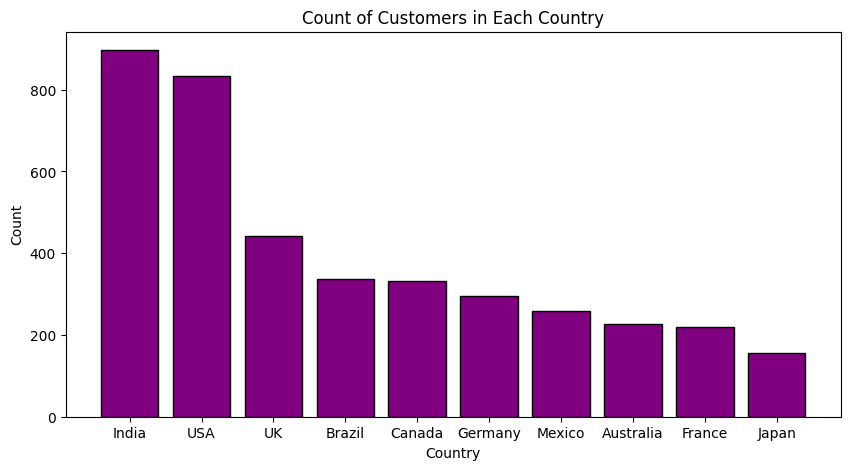

In [30]:
plt.figure(figsize=(10,5))

plt.bar(df['country'].value_counts().index,
        df['country'].value_counts().values,
         color='purple',
    edgecolor='black')

plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Count of Customers in Each Country')

plt.show()

# plot a basic line chart or bar chart showing churn counts across different devices

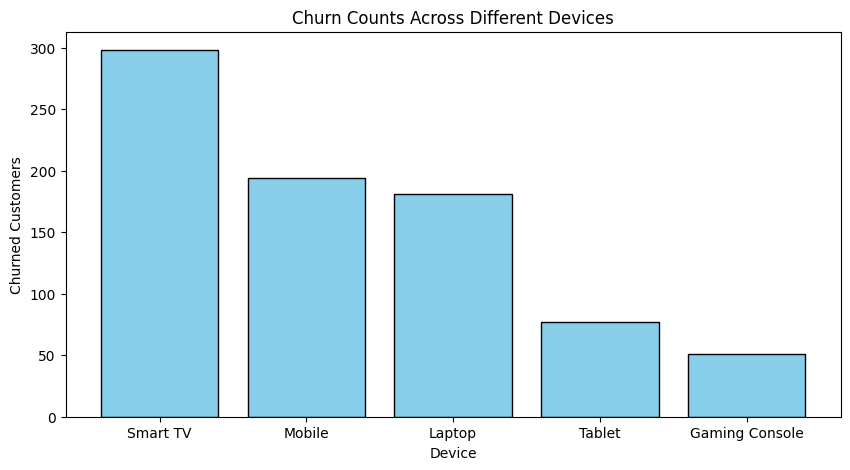

In [31]:
churned_by_device = df[df['churn'] == 1]['device'].value_counts()

plt.figure(figsize=(10,5))

plt.bar(
    churned_by_device.index,
    churned_by_device.values,
    color='skyblue',
    edgecolor='black'
)

plt.xlabel('Device')
plt.ylabel('Churned Customers')
plt.title('Churn Counts Across Different Devices')

plt.show()

# plot a simple histogram using plt.hist() to see the spread of user age

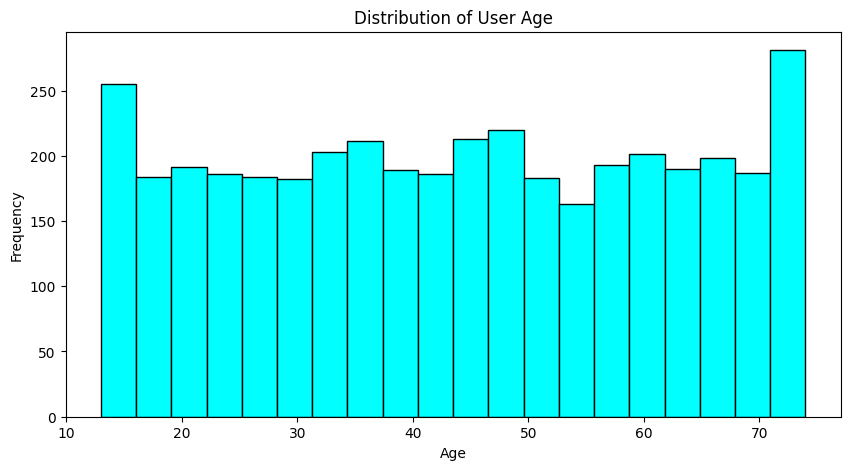

In [32]:
plt.figure(figsize=(10,5))

plt.hist(
    df['age'],
    bins=20,
    color='cyan',
    edgecolor='black'
)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of User Age')

plt.show()


# a $2 \times 2$ subplot grid (plt.subplots(2, 2)) to plot histograms showing the distributions of age, monthly_charges, tenure_months, and watch_hours_per_week

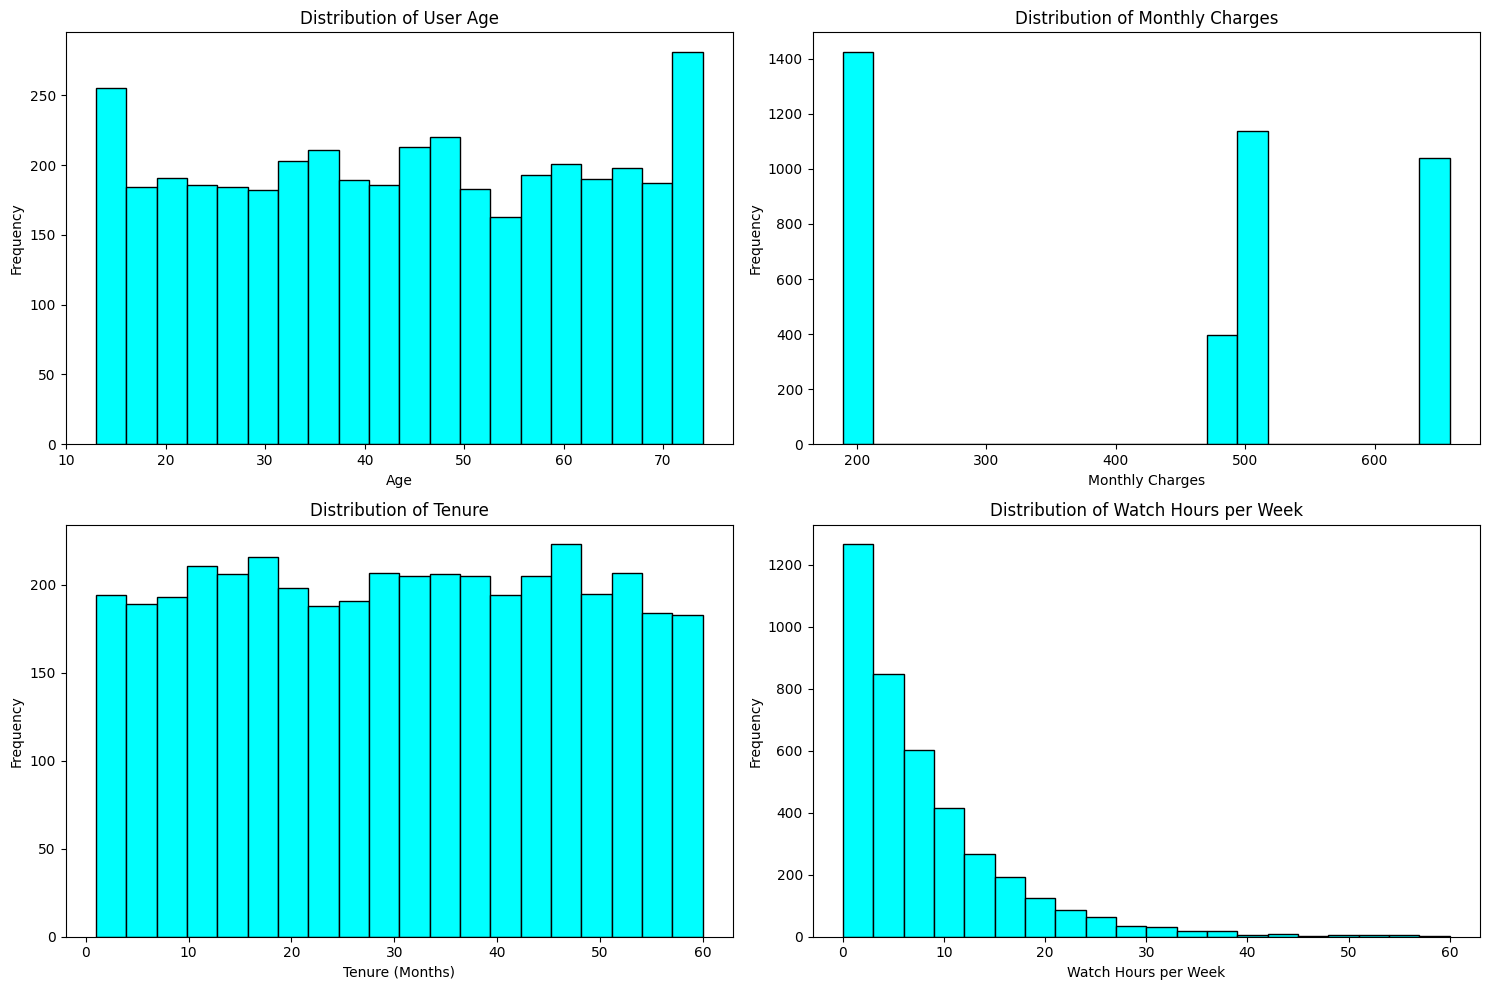

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df['age'], bins=20, color='cyan', edgecolor='black')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of User Age')

axes[0, 1].hist(df['monthly_charges'], bins=20, color='cyan', edgecolor='black')
axes[0, 1].set_xlabel('Monthly Charges')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Monthly Charges')

axes[1, 0].hist(df['tenure_months'], bins=20, color='cyan', edgecolor='black')
axes[1, 0].set_xlabel('Tenure (Months)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Tenure')

axes[1, 1].hist(df['watch_hours_per_week'], bins=20, color='cyan', edgecolor='black')
axes[1, 1].set_xlabel('Watch Hours per Week')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Watch Hours per Week')

plt.tight_layout()
plt.show()

# **Seaborn**

# a simple count plot using sns.countplot(x='churn', data=df) to visualize churn balance

/tmp/ipykernel_1975/1040514210.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df,palette={'0': 'green', '1': 'red'},


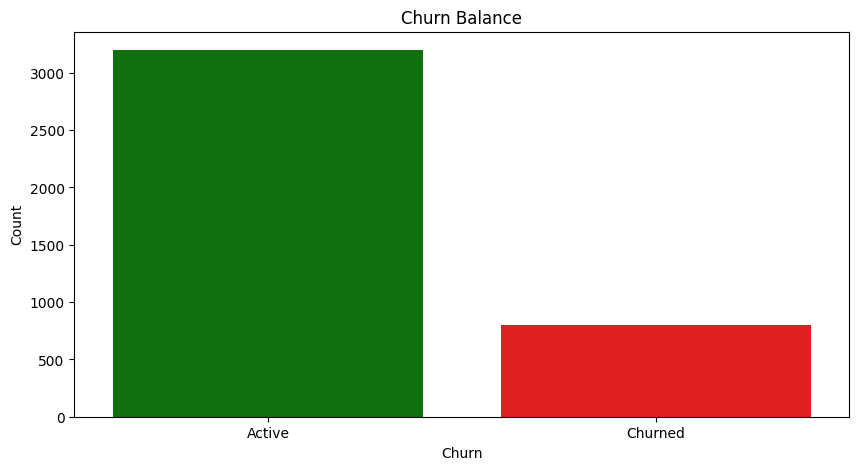

In [33]:
plt.figure(figsize=(10,5))
sns.countplot(x='churn', data=df,palette={'0': 'green', '1': 'red'},
              legend=False)

plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Churn Balance')
plt.xticks([0, 1], ['Active', 'Churned'])
plt.show()

# use sns.countplot(x='subscription_type', hue='churn', data=df) to see which plan churns the most

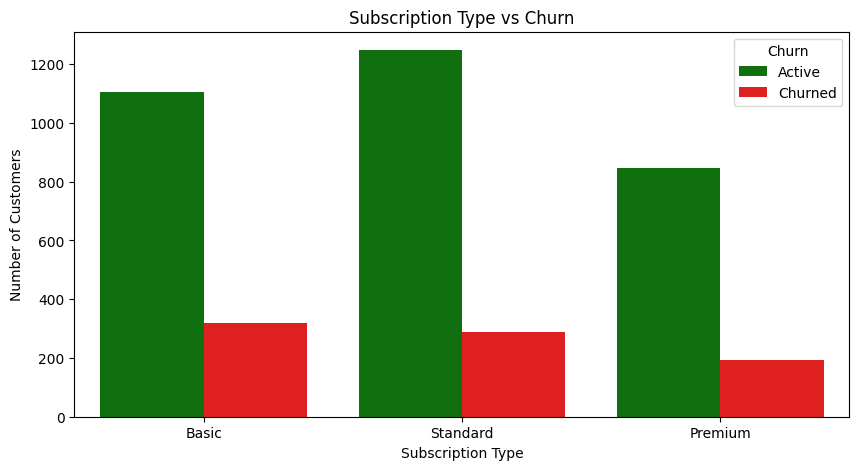

In [34]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='subscription_type',
    hue='churn',
    palette={0: 'green', 1: 'red'}
)

plt.xlabel('Subscription Type')
plt.ylabel('Number of Customers')
plt.title('Subscription Type vs Churn')

plt.legend(title='Churn', labels=['Active', 'Churned'])

plt.show()

# sns.boxplot(x='churn', y='watch_hours_per_week', data=df) to compare watch time between churned and active users

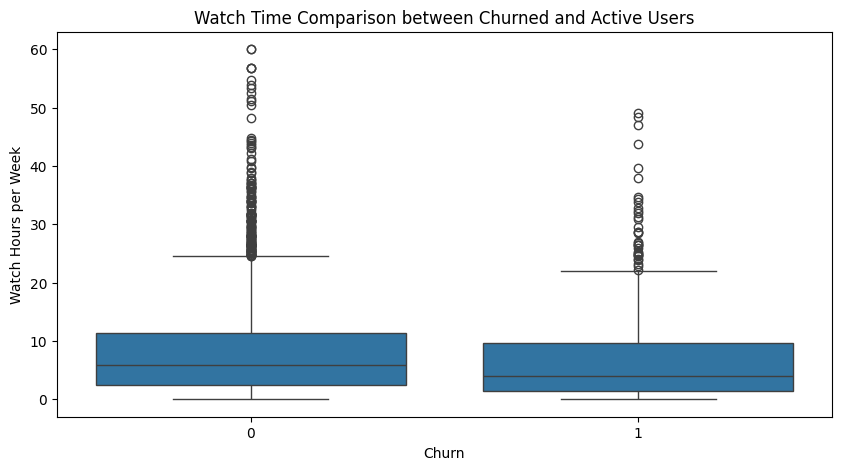

In [35]:
plt.figure(figsize=(10,5))
sns.boxplot(x='churn', y='watch_hours_per_week', data=df)
plt.xlabel('Churn')
plt.ylabel('Watch Hours per Week')
plt.title('Watch Time Comparison between Churned and Active Users')
plt.show()


# a simple sns.heatmap(df.corr(numeric_only=True), annot=True) to see which numbers relate to each other

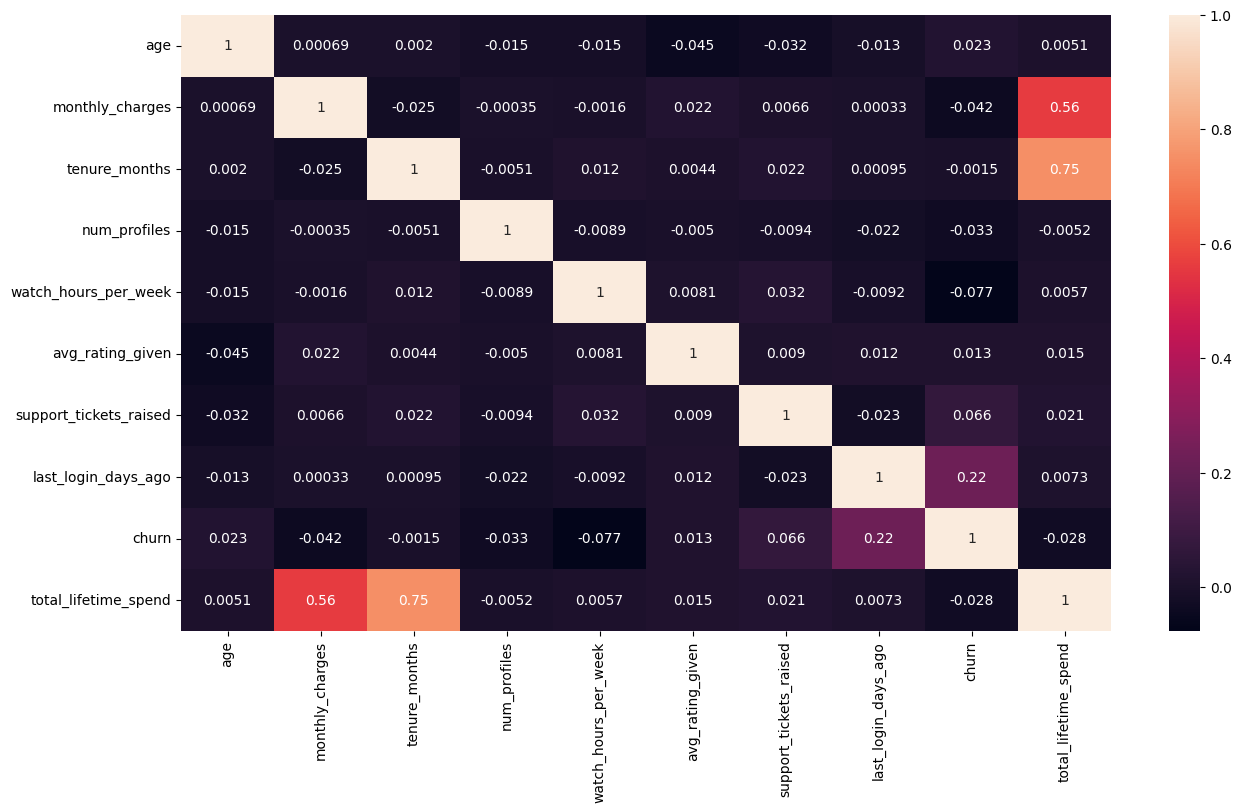

In [37]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# visualize the relationship between tenure_months and monthly_charges using sns.scatterplot(), colored by churn status

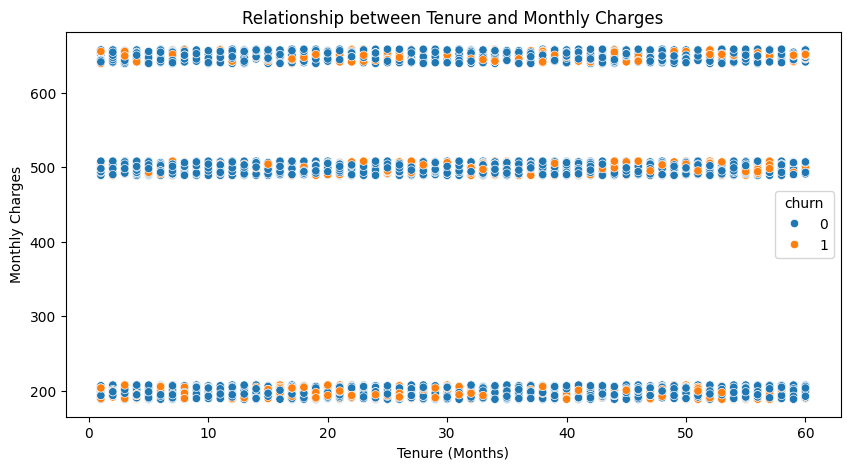

In [40]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='tenure_months', y='monthly_charges', hue='churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')
plt.title('Relationship between Tenure and Monthly Charges')
plt.show()
